# XMM-SAS 19 validation: using `evselect` with mask image to produce spectra and light-curves 

This is a new functionality in the filtering expression of `evselect`, where the user can provide an image with valid WCS as a mask. Events falling on non-zero pixels of the mask will be retained in the filtered set.

_Ivan Valtchanov_, Aug-Sep 2020

## Set up

* Working on my Linux desktop `xmml72`.
* Source `HEADAS` and `XMM_SAS`, using a shell script `start_sas19.sh`.
* Scripts/notebooks and this report are in folder `~/Dropbox/Works/XMM/sasval19`.

## Testing dataset

I will use the observation of the supernova remnant `G12.5-09` with SAS validation processing results in `/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/`. The processed event lists are used as they are (no `e[mp]chain` run).

## Testing procedure

1. Generate MOS1/pn image from the mos1/pn event list, using energy band [1,2] keV, allow for images with different `binSize`, i.e. pixel size. Experiment with `binSize=20` (1"/pixel) and `binSize=80` (default, 4"/pixel). 
2. Use the generated MOS1/pn image to create a mask with a circular region centred on `(RA_OBJ,DEC_OBJ)` from the MOS1/pn image header and with radius 1 arcmin.
2. Create two filtering expression for `evselect`: one with `(RA,DEC) in CIRCLE(RA_OBJ,DEC_OBJ,radius)` and another one with `IMAGE(<X_mask_image>)`
3. Spectral extraction:
    1. Extract with `evselect` two output spectra with the two filtering expressions (all the other parameters are identical).
    1. Compare the two output spectra.
    1. Try with a mask image with no overlap with the observation (i.e. changing CRVAL2 to be more than 1 degree away) and check `evselect`.
    1. Try with a mask image with much smaller size; the current MOS1 image with `binSize=80` is of shape 648x648 pixels, will try with 100x100 pixels.
4. Light-curve extraction:
    1. Extract with `evselect` two output light curves with the two filtering expressions (all the other parameters are identical) in different energy bands. No barycenter correction.
    1. Correct the light-curves with `epiclccorr`
    1. Compare the two output light curves

## Further testing ideas (not done at the moment)

* Choose a different region at large off-axis angle.
* Test with complex more region and multiple regions.
* Test with mask image with no WCS


In [1]:
import os
import subprocess
import sys
#import requests
#import tarfile
import logging
import glob

import numpy as np

from astropy.io import fits

%matplotlib inline

import matplotlib.pylab as plt

from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm, PercentileInterval, ImageNormalize, ManualInterval
from astropy.nddata import Cutout2D

from regions import CircleSkyRegion

import pysas

sasval19_dir = os.path.expanduser('~') + "/Dropbox/Work/XMM/xmmpy/sasval19"
sys.path.append(sasval19_dir)

In [2]:
import sasval19_tools as st19

## Set up XMM-SAS 19

Apparently having SAS in the terminal from where I started jupyterlab is not sufficient to have it available in the notebook, so I have to set this up

In [3]:
#sas_dir = '/sasbuild/installed/sasbld03n/GNU_CC_CXX_9.2.0/xmmsas_20200817_0927'
sas_dir = '/xdata/sasbuild/build/sasbld03n/GNU_CC_CXX_9.2.0/reltrack_rel_9.2.0_build'
os.environ["SAS_DIR"]= sas_dir
os.environ["SAS_PATH"]=os.environ["SAS_DIR"]
#os.environ["SAS_CCFPATH"]= "/ccf/valid"
os.environ["SAS_CCFPATH"]= "/xdata/ccf/pub"
#
os.environ["SAS_VERBOSITY"]="4"
os.environ["SAS_SUPPRESS_WARNING"]="1"
path = os.environ["PATH"]
os.environ["PATH"] = f"{sas_dir}/bin:{sas_dir}/binextra:{path}"

In [4]:
# if we are on the release track
#
if "reltrack" in sas_dir:
    # missing libqt
    os.environ['LD_LIBRARY_PATH'] += ":/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/qt-x11-free/lib:/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/cfitsio/lib"
#
print (os.environ['LD_LIBRARY_PATH'])

/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/cfitsio/lib:/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/qt-x11-free/lib:/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/gcc/lib64:/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/python/lib:/xdata/sasbuild/build/sasbld03n/GNU_CC_CXX_9.2.0/reltrack_rel_9.2.0_build/libsys:/xdata/sasbuild/build/sasbld03n/GNU_CC_CXX_9.2.0/reltrack_rel_9.2.0_build/libextra:/xdata/sasbuild/build/sasbld03n/GNU_CC_CXX_9.2.0/reltrack_rel_9.2.0_build/lib:/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/heasoft-6.27.2/x86_64-pc-linux-gnu-libc2.27/lib:/home/ivaltchanov/soft/lib:/home/ivaltchanov/soft/lib:/home/ivaltchanov/soft/lib:/home/ivaltchanov/soft/lib:/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/qt-x11-free/lib:/sasbuild/local/sasbld03n/GNU_CC_CXX_9.2.0/cfitsio/lib


## Set up the input/output folders

Also the validation dataset, whicih for these tests is `G21.5-09` a supernova remnant (extended source)

In [5]:
#
# set up the folders
#
svdata = '/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927'
# M31
#rev_obsid = '2847_0761970101'
# G21.5-9
rev_obsid = '0060_0122700101'
#
wdir = f'{svdata}/{rev_obsid}'
home = os.path.expanduser('~')
outdir = f'{home}/Works/XMM/sasval19/evselect_tests'
if (not os.path.isdir(outdir)):
    os.mkdir(outdir)
#
# and set the SAS_CCF
#
os.environ["SAS_CCF"]= f"{wdir}/ccf.cif"
#

## Set up the logging file

This file will hold all stdin/stdout/stderr outputs.

In [6]:
logging.basicConfig(level=logging.DEBUG,
                    format='%(asctime)s %(levelname)s %(message)s',
                    filename=f'{outdir}/{rev_obsid}_mos1_mask.log',
                    filemode='w')


In [7]:
#
# now get the available event lists an assign the filenames
#
evl = {}
evlists = glob.glob(f'{wdir}/*_ImagingEvts*.ds')
for q in evlists:
    if ('EMOS1' in q):
        evl['m1'] = q
    elif ('EMOS2' in q):
        evl['m2'] = q
    elif ('EPN' in q):
        evl['pn'] = q
    else:
        print (f'Cannot assign event list to EPIC: {q}')
        logger.warning(f'Cannot assign event list to EPIC: {q}')

In [8]:
evlists

['/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EMOS1_S002_ImagingEvts.ds',
 '/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EMOS2_S003_ImagingEvts.ds',
 '/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds']

## Create MOS1 image

Will use an arbitrary band `[1000,2000]` eV, we don't care about the band, we need an image with WCS. Allowing for different `binSize`, which dictate the pixel size.

In [9]:
#
# make MOS1 image in an arbitrary band, just to have a WCS
#
imfile = {}
binsize = 80 # 
imfile["80"] = st19.make_images(evl['m1'],energy_range=(1000,2000),bin_size=binsize,save_prefix=f'{outdir}/m1_{rev_obsid}_{binsize}')
#
binsize = 20 # 
imfile["20"] = st19.make_images(evl['m1'],energy_range=(1000,2000),bin_size=binsize,save_prefix=f'{outdir}/m1_{rev_obsid}_{binsize}')

Execution of evselect table=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EMOS1_S002_ImagingEvts.ds xcolumn=X ycolumn=Y imagebinning=binSize ximagebinsize=80 yimagebinsize=80 expression='(PI in [1000:2000]) && ((FLAG & 0x766ba000)==0) && (PATTERN<=12)' withimageset=true imageset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_80_1000_2000.fits returned 0


Image in band [1000,2000] eV saved to /home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_80_1000_2000.fits
Image in band [1000,2000] eV saved to /home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_20_1000_2000.fits


Execution of evselect table=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EMOS1_S002_ImagingEvts.ds xcolumn=X ycolumn=Y imagebinning=binSize ximagebinsize=20 yimagebinsize=20 expression='(PI in [1000:2000]) && ((FLAG & 0x766ba000)==0) && (PATTERN<=12)' withimageset=true imageset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_20_1000_2000.fits returned 0


## Creating a mask image

Will use the generated MOS1 image, the mask region will be centred on `(RA_OBJ,DEC_OBJ)` as read from the MOS1 image FITS header and will make an aperture with this centre and 1 arcmin radius.

Then this aperture is converted to pixels using the WCS and the maks is converted to the original image dimensions, with 0 and 1 for the aperture. 

In [10]:
fileout = {}
for xbin in imfile.keys():
    qfile = imfile[xbin]
    hdu = fits.open(qfile)
    wcs = WCS(hdu[0].header)
    #
    # get centre from FITS header
    #
    centre = SkyCoord(hdu[0].header['RA_OBJ'],hdu[0].header['DEC_OBJ'],unit='deg',frame='icrs')
    aperture = CircleSkyRegion(centre,1.0*u.arcmin)
    mask = aperture.to_pixel(wcs).to_mask(mode='exact')
    #
    # save the masked image
    #
    fileout[xbin] = qfile.replace('.fits',f'_mask.fits')
    hdu[0].data = mask.to_image(hdu[0].data.shape)
    hdu[0].data = hdu[0].data.astype('uint8')
    hdu.writeto(fileout[xbin],overwrite=True)
    hdu.close()
    print (f'Mask image created: {fileout[xbin]}')

Mask image created: /home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_80_1000_2000_mask.fits
Mask image created: /home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_20_1000_2000_mask.fits


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


## Create a smaller (zoomed) mask image

This is for an additional test on the behaviour. Filename will have `*_mask_zoom` in the name. Will only do this with the mask image of 4"/pixel.

In [11]:
#
# now use the generated mask image and cut it out to a smaller size
#
xbox=5 # arcmin box
zoom_out = fileout["80"].replace('_mask.fits',f'_mask_zoom{xbox:.0f}.fits')
with fits.open(fileout["80"]) as hdux:
    cutout_image(hdux,centre,xbox,out_name=zoom_out,clobber=False)

NameError: name 'cutout_image' is not defined

## Display the image and the aperture with its bounding box

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


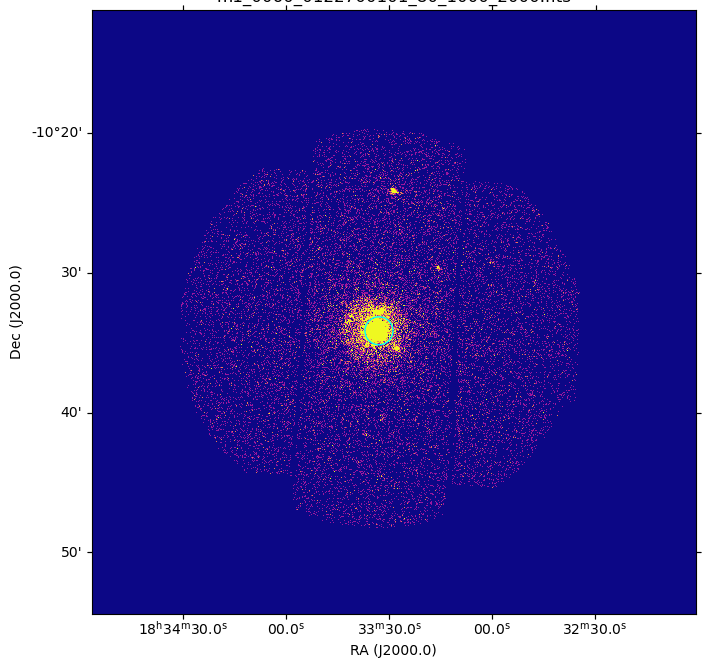

In [14]:
#hdu = fits.open(zoom_out)
hdu = fits.open(imfile["80"])
wcs = WCS(hdu[0].header)
##
## get centre from FITS header
##
#centre = SkyCoord(hdu[0].header['RA_OBJ'],hdu[0].header['DEC_OBJ'],unit='deg',frame='icrs')
#aperture = CircleSkyRegion(centre,1.0*u.arcmin)
#mask = aperture.to_pixel(wcs).to_mask(mode='exact')
#
fig = plt.figure(figsize=(15,8),dpi=100)
#
pp = 99.5 #
ax = fig.add_subplot(projection=wcs)
ax.set_title(f"{os.path.basename(imfile['80'])}")
lon = ax.coords['ra']
lon.set_axislabel('RA (J2000.0)')
lon.set_major_formatter('hh:mm:ss.s')
lat = ax.coords['dec']
lat.set_major_formatter('dd:mm')
lat.set_axislabel('Dec (J2000.0)')
# now normalize the imahe
norm = ImageNormalize(hdu[0].data, interval=PercentileInterval(pp))
ax.imshow(hdu[0].data,norm=norm,cmap=plt.cm.plasma,origin='lower',interpolation='nearest')
#
ax.add_artist(mask.bbox.as_artist(facecolor='none', edgecolor='white'))
ax.add_artist(aperture.to_pixel(wcs).as_artist(facecolor='none', edgecolor='cyan'))
#
ax.set_autoscale_on(False)
hdu.close()

## Spectral extraction

One spectrum set will be with expression based on the region and another one on expression based on mask image.

Will also generate RMF and ARF files and group the spectral bins to have at least one count. No background generation.

### Region expression

In [15]:
#
# spectrum extraction using region
#
sas_region = f"((RA,DEC) in CIRCLE({aperture.center.ra.value:.5f},{aperture.center.dec.value:.5f},{aperture.radius.to(u.deg).value:.5f}))"
#
spec_reg = f"{outdir}/{rev_obsid}_pn_spectrum_region.fits"
#
expr1 = "(FLAG==0) && (PATTERN<=4) && " + sas_region
print (expr1)
#
st19.make_spectrum(evl['pn'],expr1,spec_reg,do_rmf_arf_grp=True)
#

(FLAG==0) && (PATTERN<=4) && ((RA,DEC) in CIRCLE(278.38750,-10.56944,0.01667))
Extracting spectrum


Execution of evselect table=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds withspectrumset=yes spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits energycolumn=PI spectralbinsize=5 withspecranges=yes specchannelmin=0 specchannelmax=20479 expression='(FLAG==0) && (PATTERN<=4) && ((RA,DEC) in CIRCLE(278.38750,-10.56944,0.01667))' returned 0


Running rmfgen, can take time...


Execution of rmfgen spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits rmfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits.rmf returned 0


Running arfgen, can take time...


Execution of arfgen spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits withrmfset=yes rmfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits.rmf extendedsource=yes badpixlocation=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds detmaptype=flat arfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits.xarf returned 0
Execution of specgroup spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits addfilenames=yes rmfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits.rmf arfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits.xarf groupedset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits.grp 

### Using mask image

In [16]:
#
# spectrum extraction using mask image
#
spec_image = {}
for xbin in ["80","20"]:
    spec_image[xbin] = f"{outdir}/{rev_obsid}_pn_spectrum_image_{binsize}.fits"
    expr1 = "(FLAG==0) && (PATTERN<=4) && " + f"IMAGE(\"{fileout[xbin]}\")"
    print (expr1)
    st19.make_spectrum(evl['pn'],expr1,spec_image[xbin],do_rmf_arf_grp=True)

(FLAG==0) && (PATTERN<=4) && IMAGE("/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_80_1000_2000_mask.fits")
Extracting spectrum


Execution of evselect table=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds withspectrumset=yes spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits energycolumn=PI spectralbinsize=5 withspecranges=yes specchannelmin=0 specchannelmax=20479 expression='(FLAG==0) && (PATTERN<=4) && IMAGE("/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_80_1000_2000_mask.fits")' returned 0


Running rmfgen, can take time...


Execution of rmfgen spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits rmfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits.rmf returned 0


Running arfgen, can take time...


...

Execution of evselect table=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds withspectrumset=yes spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits energycolumn=PI spectralbinsize=5 withspecranges=yes specchannelmin=0 specchannelmax=20479 expression='(FLAG==0) && (PATTERN<=4) && IMAGE("/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_20_1000_2000_mask.fits")' returned 0


Running rmfgen, can take time...


Execution of rmfgen spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits rmfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits.rmf returned 0


Running arfgen, can take time...


Execution of arfgen spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits withrmfset=yes rmfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits.rmf extendedsource=yes badpixlocation=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds detmaptype=flat arfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits.xarf returned 0
Execution of specgroup spectrumset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits addfilenames=yes rmfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits.rmf arfset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_20.fits.xarf groupedset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_imag

### Comparing the extracted spectra

Will include two cases of mask image pixel size: 1"/pixel (`binSize=20`) and 4"\pixel (`binSize=80`, default in `evselect`).

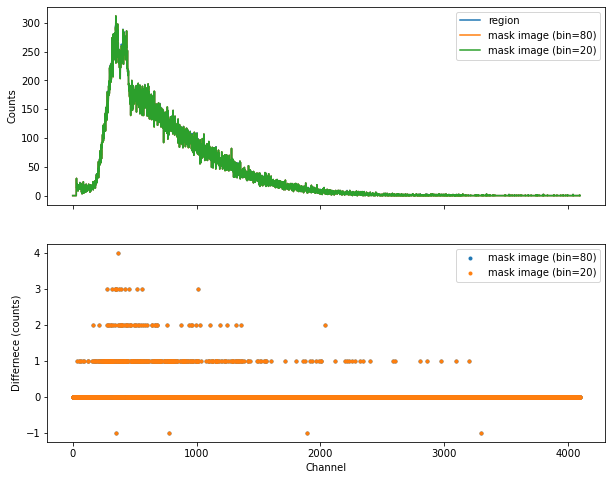

In [17]:
#
# let's compare the two spectra
#
#
# and compare with image with binsize=20 (1"/pixel)
spec_image20 = f"{outdir}/{rev_obsid}_pn_spectrum_image_20.fits"
spec_image80 = f"{outdir}/{rev_obsid}_pn_spectrum_image_80.fits"

fig, ax = plt.subplots(2,1,sharex=True,figsize=(10,8))
#
with fits.open(spec_reg) as s1:
    chan1 = s1['SPECTRUM'].data["CHANNEL"]
    counts1 = s1['SPECTRUM'].data["COUNTS"]
#
ax[0].plot(chan1,counts1,label='region')
#
for xbin in ["80","20"]:
    with fits.open(spec_image[xbin]) as sx:
        xchan = sx['SPECTRUM'].data["CHANNEL"]
        xcounts = sx['SPECTRUM'].data["COUNTS"]
    ax[0].plot(xchan,xcounts,label=f'mask image (bin={xbin})')
    ax[1].plot(chan1,counts1-xcounts,'.',label=f'mask image (bin={xbin})')
#
ax[1].set_xlabel('Channel')
ax[0].set_ylabel('Counts')
ax[1].set_ylabel('Differnece (counts)')
ax[0].legend()
ax[1].legend()
#plt.savefig(f'{outdir}/spec_comparison_m1_mask.png',dpi=100)
plt.show()
plt.close();

## Compare the ARF generated files, `extendedsource=yes`

FileNotFoundError: [Errno 2] No such file or directory: '/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_image_80.fits.xarf'

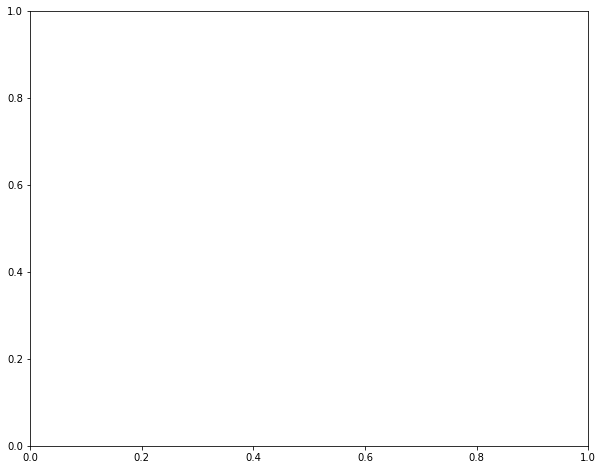

In [18]:
#
# let's compare the two ARF files, extendedsource=yes case
#
arf_reg = f"{outdir}/{rev_obsid}_pn_spectrum_region.fits.xarf"
arf_im20 = f"{outdir}/{rev_obsid}_pn_spectrum_image_20.fits.xarf"
arf_im80 = f"{outdir}/{rev_obsid}_pn_spectrum_image_80.fits.xarf"
#
fig, ax = plt.subplots(figsize=(10,8))

with fits.open(arf_reg) as hdu_reg, fits.open(arf_im20) as hdu_im20, fits.open(arf_im80) as hdu_im80:
    x1 = hdu_reg["SPECRESP"].data['ENERG_LO']
    y1 = hdu_reg["SPECRESP"].data['SPECRESP']
    x2 = hdu_im20["SPECRESP"].data['ENERG_LO']
    y2 = hdu_im20["SPECRESP"].data['SPECRESP']
    x3 = hdu_im80["SPECRESP"].data['ENERG_LO']
    y3 = hdu_im80["SPECRESP"].data['SPECRESP']
    ax.plot(x1,y1/y2,label='ARF(reg)/ARF(20)')
    ax.plot(x1,y1/y3,label='ARF(reg)/ARF(80)')
ax.set_ylabel('Ratio ARF(reg)/ARF(image)')
ax.set_xlabel('Energy (keV)')
ax.grid()
ax.legend()
plt.savefig(f'{outdir}/arf_comparison_extended.png',dpi=100)
plt.show()
plt.close();
#ax.plot(x2,y2)
#

## Compare the ARF generated files, PSF correction

FileNotFoundError: [Errno 2] No such file or directory: '/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_spectrum_region.fits.arf'

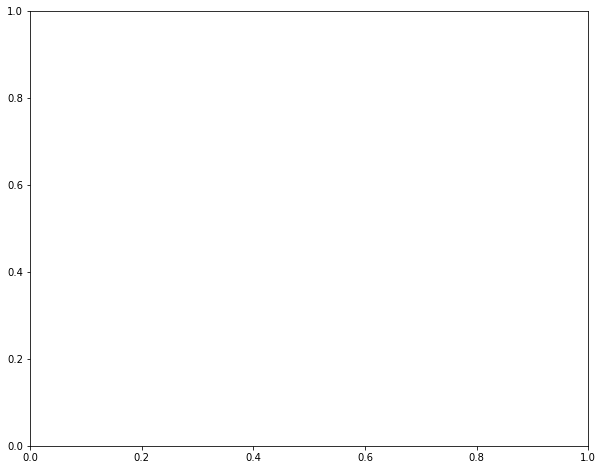

In [19]:
#
# let's compare the two ARF files
#
arf_reg = f"{outdir}/{rev_obsid}_pn_spectrum_region.fits.arf"
arf_im20 = f"{outdir}/{rev_obsid}_pn_spectrum_image_20.fits.arf"
arf_im20z = f"{outdir}/{rev_obsid}_pn_spectrum_image_20_zoom.fits.arf"
arf_im80 = f"{outdir}/{rev_obsid}_pn_spectrum_image_80.fits.arf"
#
fig, ax = plt.subplots(figsize=(10,8))

with fits.open(arf_reg) as hdu_reg, fits.open(arf_im20) as hdu_im20, fits.open(arf_im80) as hdu_im80, fits.open(arf_im20z) as hdu_im20z:
    x1 = hdu_reg["SPECRESP"].data['ENERG_LO']
    y1 = hdu_reg["SPECRESP"].data['SPECRESP']
    x2 = hdu_im20["SPECRESP"].data['ENERG_LO']
    y2 = hdu_im20["SPECRESP"].data['SPECRESP']
    x3 = hdu_im80["SPECRESP"].data['ENERG_LO']
    y3 = hdu_im80["SPECRESP"].data['SPECRESP']
    x4 = hdu_im20z["SPECRESP"].data['ENERG_LO']
    y4 = hdu_im20z["SPECRESP"].data['SPECRESP']
    ax.plot(x1,y1/y2,label='ARF(reg)/ARF(20)')
    ax.plot(x1,y1/y3,label='ARF(reg)/ARF(80)')
    ax.plot(x1,y1/y4,label='ARF(reg)/ARF(20 zoom)')
ax.set_ylabel('Ratio ARF(reg)/ARF(image)')
ax.set_xlabel('Energy (keV)')
ax.grid()
ax.legend()
plt.savefig(f'{outdir}/arf_comparison_test1.png',dpi=100)
plt.show()
plt.close();
#ax.plot(x2,y2)
#

## Testing generated light-curves

In [21]:
#
# Rate curve with region selection
# band [500,2000] eV
# band [2000,10000]
#rate_reg = f"{outdir}/{rev_obsid}_pn_rate_500_2000_region.fits"
rate_reg = f"{outdir}/{rev_obsid}_pn_rate_2000_10000_region.fits"
#
#expr1 = "(FLAG==0) && (PATTERN<=4) && (PI in [500:2000]) && " + sas_region
expr1 = "(FLAG==0) && (PATTERN<=4) && (PI in [2000:10000]) && " + sas_region
corr_rate_reg = st19.make_lightcurve(evl['pn'],expr1,rate_reg)

Extracting rate curve


Execution of evselect table=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds withspectrumset=no energycolumn=PI withrateset=yes rateset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_rate_2000_10000_region.fits timebinsize=100 maketimecolumn=yes makeratecolumn=yes expression='(FLAG==0) && (PATTERN<=4) && (PI in [2000:10000]) && ((RA,DEC) in CIRCLE(278.38750,-10.56944,0.01667))' returned 0


Correcting rate curve


Execution of epiclccorr srctslist=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_rate_2000_10000_region.fits eventlist=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds outset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_rate_2000_10000_region_corr.fits withbkgset=no applyabsolutecorrections=no returned 0


In [23]:
#
# Rate curve with region selection
# band [500,2000] eV
#rate_image = f"{outdir}/{rev_obsid}_pn_rate_500_2000_image.fits"
rate_image = f"{outdir}/{rev_obsid}_pn_rate_2000_10000_image.fits"
#
#expr1 = "(FLAG==0) && (PATTERN<=4) && (PI in [500:2000]) && " + f"IMAGE(\"{fileout}\")"
expr1 = "(FLAG==0) && (PATTERN<=4) && (PI in [2000:10000]) && " + f"IMAGE(\"{fileout['80']}\")"
corr_rate_image = st19.make_lightcurve(evl['pn'],expr1,rate_image)

Extracting rate curve


Execution of evselect table=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds withspectrumset=no energycolumn=PI withrateset=yes rateset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_rate_2000_10000_image.fits timebinsize=100 maketimecolumn=yes makeratecolumn=yes expression='(FLAG==0) && (PATTERN<=4) && (PI in [2000:10000]) && IMAGE("/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/m1_0060_0122700101_80_1000_2000_mask.fits")' returned 0


Correcting rate curve


Execution of epiclccorr srctslist=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_rate_2000_10000_image.fits eventlist=/xdata/sasval/archive/product/SAS_19.0.0_GNU_CC_CXX_9.2.0/xmmsas_20200817_0927/0060_0122700101/0060_0122700101_EPN_S001_ImagingEvts.ds outset=/home/ivaltchanov/Works/XMM/sasval19/evselect_tests/0060_0122700101_pn_rate_2000_10000_image_corr.fits withbkgset=no applyabsolutecorrections=no returned 0


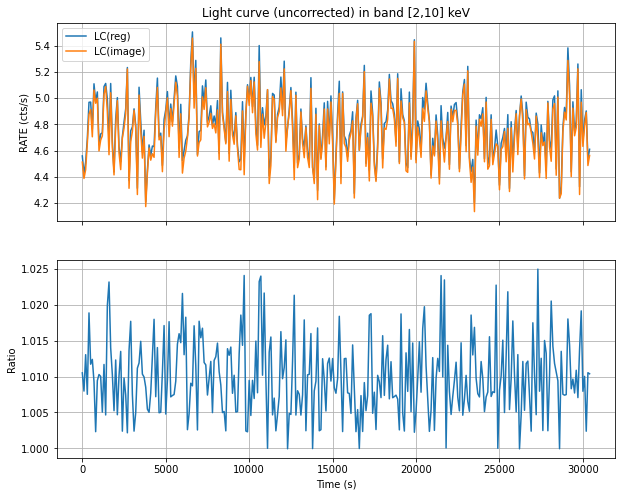

In [24]:
#
# let's compare the two uncorrected rate files
#
fig, ax = plt.subplots(2,1,sharex=True, figsize=(10,8))

with fits.open(corr_rate_reg) as hdu_reg, fits.open(corr_rate_image) as hdu_im:
    x1 = hdu_reg["RATE"].data['TIME'] - hdu_reg["RATE"].data['TIME'].min()
    y1 = hdu_reg["RATE"].data['RATE']
    x2 = hdu_im["RATE"].data['TIME'] - hdu_im["RATE"].data['TIME'].min()
    y2 = hdu_im["RATE"].data['RATE']
    ax[0].plot(x1,y1,label='LC(reg)')
    ax[0].plot(x2,y2,label='LC(image)')
    ax[1].plot(x1,y1/y2,label='LC(reg)/LC(im)')
ax[0].set_ylabel('RATE (cts/s)')
#ax[0].set_xlabel('Time (s)')
ax[0].grid()
ax[0].legend()
ax[1].set_ylabel('Ratio')
ax[1].set_xlabel('Time (s)')
ax[1].grid()
ax[0].set_title('Light curve (uncorrected) in band [2,10] keV')
plt.savefig(f'{outdir}/lc_mos1_mask_band_2000_10000_corr.png',dpi=100)
#ax[0].set_title('Light curve (uncorrected) in band [500,2000] eV')
#plt.savefig(f'{outdir}/lc_mos1_mask_band_500_2000.png',dpi=100)
plt.show()
plt.close();


## Results on spectra

Running `evselect` with `IMAGE()` filtering expression. 

1. The masked image must be integer, if not then `evselect` fails with an error:

```
PRIMARY passed to the mask filter is not of integral (int8/16/32/uint16/32) or boolean type - cannot proceed
```
This is documented, so not a problem.

2. A warning message, which I am not sure is important or not:

```
warning (DssCompForm), Two 2-d filters with the name POS have been found to different components. Cannot write data subspace.
```

3. Using MOS1-based mask image:
    1. Comparing the spectra filtered with MOS1 mask with 1"/pixel and 4"/pixel against filtering with a region shows the expected behaviour ![this figure](spec_comparison_m1_mask.png).
        - the differences are minimal: 4 or 8 counts out of 300 for 1"/pixel or 4"/pixel masks respectively. This is obviously the effect of the pixel binning.
    2. Using mask image with very different sky position do not result in error message but `evselect` produce warning that no events were selected. This is correct behaviour.
    3. Using zoomed in image with 300x300 pixels, cropping the MOS1 mask image to 5x5 arcmin. The results are identical with the non-cropped, original size MOS1 image.
    4. Checking the produced ARF files, `arfgen` was executed with the same parameters, the differences are the RMF files and the input spectral sets.
        - Huge difference in the ARF files, comparing the two 'SPECRESP' extensions. See bellow
 ![arf comparison](arf_comparison_test1.png)
        - The ARF ratio depends also on the mask image pixel size! This cannot be correct, unless I am missing something important.
    5. Checking the produced ARF files with `arfgen` and using `extendedsource=yes` option. This time the ratio of the effective areas is as expected:
 ![arf comparison extended](arf_comparison_extended.png)
        - the ratio is below 1.01 (i.e. 1%) for energies below 9 keV and the ratio is slightly better (closer to 1) for mask image with 1"/pixel.

4. Using pn-based mask image:
    1. Comparing the spectra filtered with pn mask with 4"/pixel against filtering with a region shows the expected behaviour ![this figure](spec_comparison_pn_mask.png).
        - the differences are minimal: max 6 counts out of 150 for 4"/pixel mask.
    2. Checking the produced ARF files, `arfgen` was executed with the same parameters, and `extendedsource=yes`, the differences are the RMF files and the input spectral sets. The ratio of the effective areas is as expected:
 ![arf comparison extended](arf_m1_comparison_extended.png)
        - the ratio is much below 1% for all energies.



## Results on light-curves

1. Running `evselect` with two filtering expressions to create rate files was successful. We only use MOS1-based mask image with `binSize=80` (i.e. 4"/pixel). 
2. Running `epiclccorr` on the `IMAGE()` produced rate_curve failed with the following message:
```
epiclccorr::evselect:- evselect (evselect-3.71)  [xmmsas_20200817_0927-19.0.0] started:  2020-09-04T10:38:17.000
epiclccorr::evselect:- selected 36693 rows from the input table.
** epiclccorr::evselect: error (NoRegion), No region information available for this filter type.
** epiclccorr: error (invalidInvocation), Execution failed of evselect (evselect-3.71)  [xmmsas_20200817_0927-19.0.0]
```
3. Comparing the two _uncorrected_ light-curves in two bands: `[0.5,2]` keV and `[2,10]` keV
![lc comparison 1](lc_mos1_mask_band_500_2000.png)
![lc comparison 2](lc_mos1_mask_band_2000_10000.png)
 * the ratio `LC(region)/LC(image)` is always greater than one, and of the order of 2-5%.

 


## Conclusions

 * The filtering with user provided image with WCS works as expected. 
 * The pixel size of the mask image have effect on the extracted spectra/light-curves as compared with the _standard_ region filtering.
 * The ARF for the spectra should be generated with `extendedsource=yes` option to `arfgen` for the `IMAGE()` filtered spectra.
 * The `epiclccorr` task fails for the rate table produced with `IMAGE()` filtering. 
